In [1]:
# --- parameters (injected by build_notebooks.py) ---
COMPETITION = 'titanic'
COMP_DIR = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster'
RUN_DIR = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run'
CONFIG_PATH = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/config.yaml'
TRAIN_CSV = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/data/train_fe.csv'
TEST_CSV = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/data/test_fe.csv'
TARGET = 'Survived'
ID_COL = 'PassengerId'
METRIC = 'accuracy'
RANDOM_STATE = 42
HOLDOUT_FRACTION = 0.2
MLFLOW_URI = 'sqlite:////Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run/mlflow.db'
MLFLOW_DB = '/Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run/mlflow.db'

# 📊 EDA — titanic

**Run:** `20260713-0916`  ·  generated by the `kaggle-ml-loop` skill

This notebook is the visual companion to the pipeline's `eda/` outputs. Every chart
reads the raw training data directly, so it re-runs standalone.

### Links
| What | Where |
|---|---|
| Training data | [`../data/train_fe.csv`](../data/train_fe.csv) |
| Test data | [`../data/test_fe.csv`](../data/test_fe.csv) |
| Run config | [`../config.yaml`](../config.yaml) |
| Run directory | [`../kaggle_run`](../kaggle_run) |
| EDA report (md) | [`../kaggle_run/eda/eda_report.md`](../kaggle_run/eda/eda_report.md) |
| EDA summary (json) | [`../kaggle_run/eda/eda_summary.json`](../kaggle_run/eda/eda_summary.json) |

### MLflow experiment tracking
Launch the UI to browse every run for this competition:
```bash
mlflow ui --backend-store-uri sqlite:////Users/jjespinoza/Library/CloudStorage/GoogleDrive-jj.espinoza.la@gmail.com/My Drive/Projects/MyKaggleCompetitions/competitions/TitanicMachineLearningFromDisaster/kaggle_run/mlflow.db
```
Then open **http://127.0.0.1:5000** in your browser.


In [2]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
PALETTE = "crest"
sns.set_palette(sns.color_palette(PALETTE, 8))
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

train = pd.read_csv(TRAIN_CSV)
print(f"{COMPETITION}: {train.shape[0]} rows x {train.shape[1]} columns")
train.head()

titanic: 891 rows x 16 columns


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FamilyBucket,TicketGroupSize,FarePerPerson,Deck
0,1,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,small,1,7.25000,U
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,small,2,35.64165,C
2,3,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,alone,1,7.92500,U
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,small,2,26.55000,C
4,5,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,alone,1,8.05000,U


## 1 · Shape, types, and missingness

In [3]:
def overview(df):
    o = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    })
    return o.sort_values("missing_pct", ascending=False)

overview(train)

,dtype,n_unique,missing,missing_pct
PassengerId,int64,891,0,0.0
Survived,int64,2,0,0.0
Pclass,int64,3,0,0.0
Sex,object,2,0,0.0
Age,float64,90,0,0.0
SibSp,int64,7,0,0.0
Parch,int64,7,0,0.0
Fare,float64,248,0,0.0
Embarked,object,3,0,0.0
Title,object,5,0,0.0


In [4]:
# Missingness heatmap — where are the holes?
miss = train.isna()
if miss.any().any():
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(miss, cbar=False, cmap="mako", ax=ax)
    ax.set_title("Missing values (yellow = present, dark = missing)")
    ax.set_xlabel(""); plt.tight_layout(); plt.show()
else:
    print("No missing values.")

No missing values.


## 2 · Target distribution

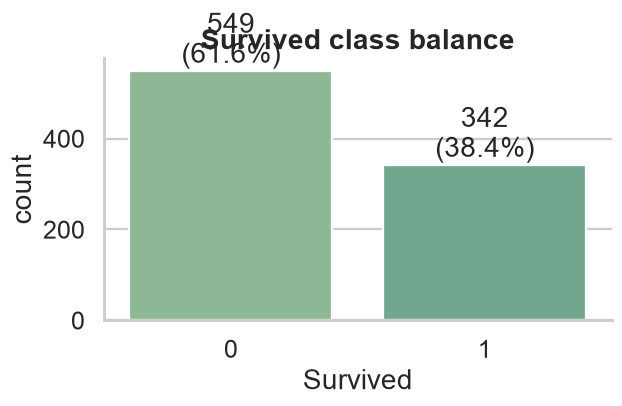

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = train[TARGET].value_counts().sort_index()
sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax, hue=vc.index.astype(str), legend=False)
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v}\n({v/len(train):.1%})", ha="center", va="bottom")
ax.set_title(f"{TARGET} class balance"); ax.set_xlabel(TARGET); ax.set_ylabel("count")
sns.despine(); plt.tight_layout(); plt.show()

## 3 · Univariate distributions

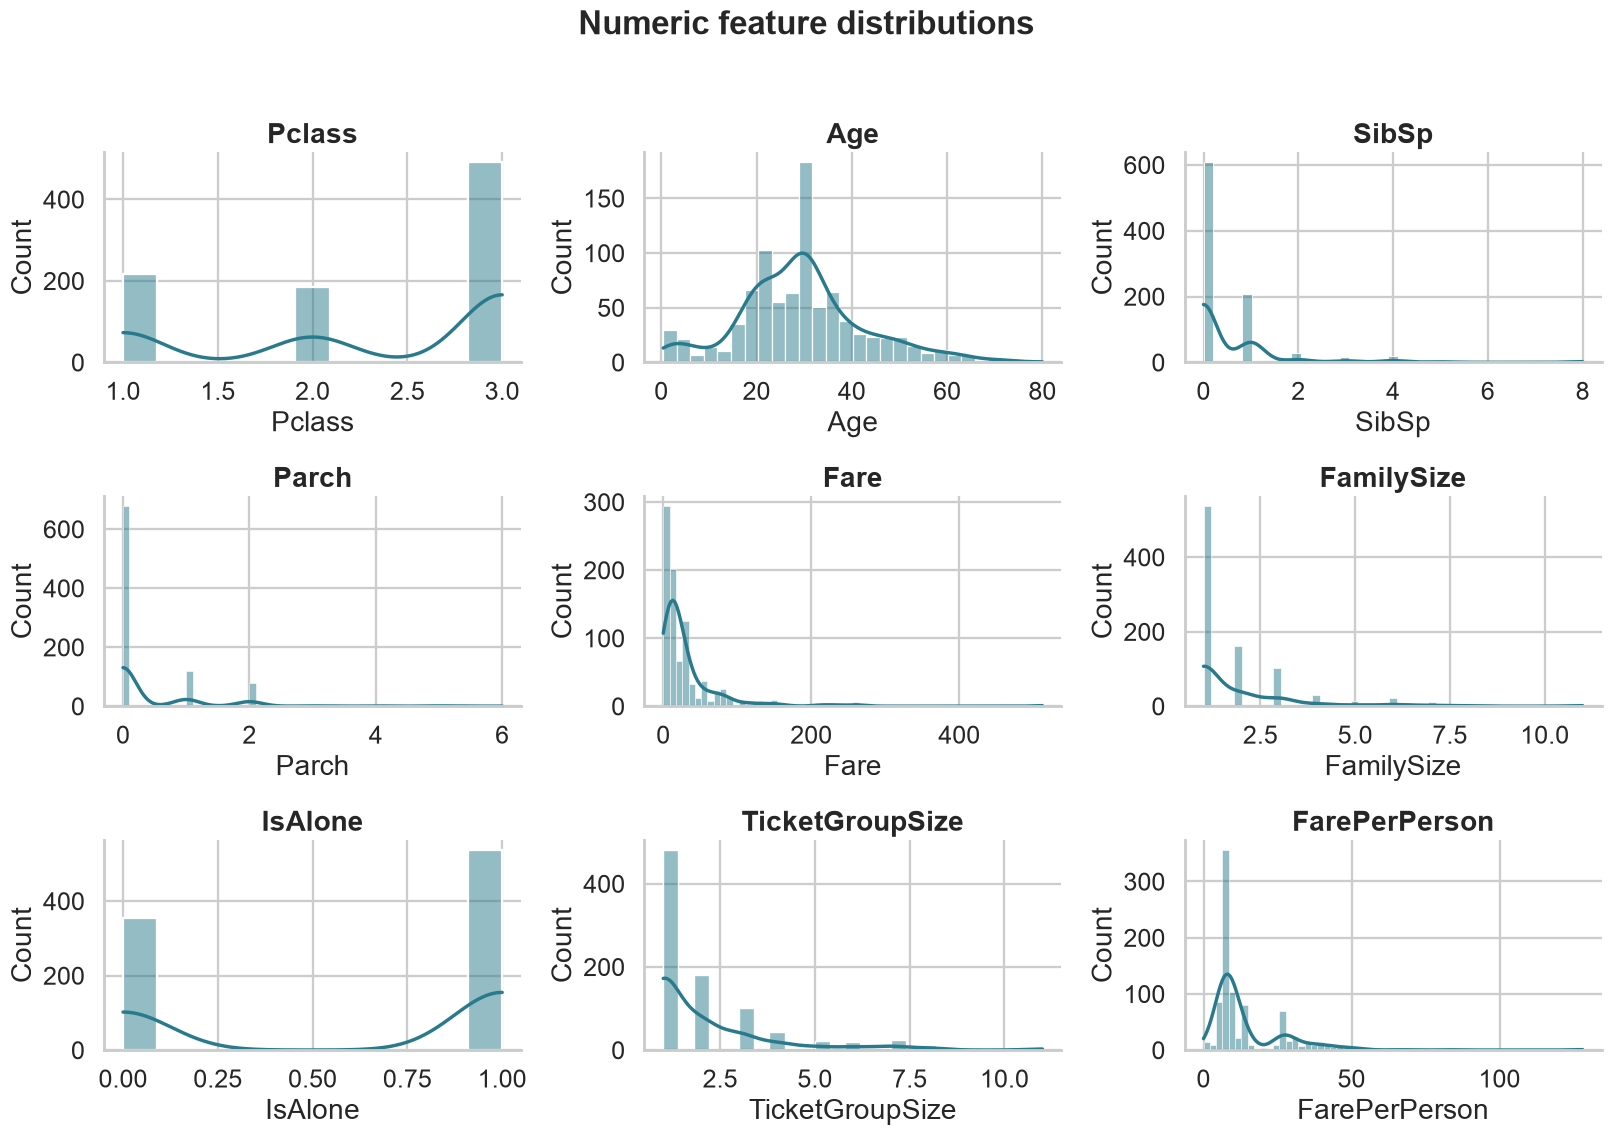

In [6]:
num_cols = [c for c in train.columns
            if c not in (TARGET, ID_COL) and train[c].dtype.kind in "biufc"]
cat_cols = [c for c in train.columns
            if c not in (TARGET, ID_COL) and c not in num_cols and train[c].nunique() <= 12]

if num_cols:
    n = len(num_cols); ncol = 3; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.4*nrow))
    for ax, c in zip(np.atleast_1d(axes).ravel(), num_cols):
        sns.histplot(train[c].dropna(), kde=True, ax=ax, color=sns.color_palette(PALETTE)[3])
        ax.set_title(c)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle("Numeric feature distributions", y=1.02, fontweight="bold")
    sns.despine(); plt.tight_layout(); plt.show()

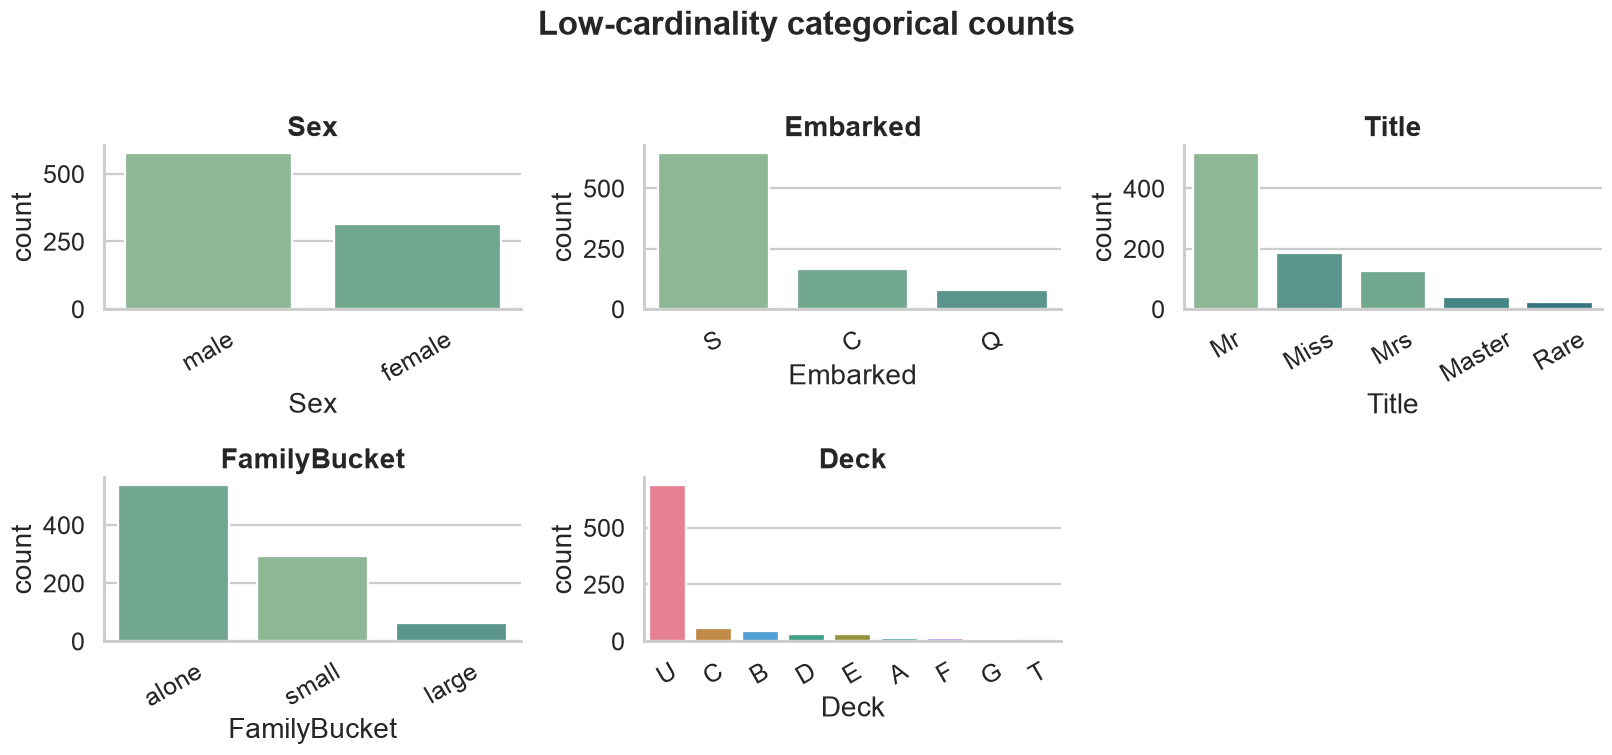

In [7]:
if cat_cols:
    n = len(cat_cols); ncol = 3; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.4*nrow))
    for ax, c in zip(np.atleast_1d(axes).ravel(), cat_cols):
        order = train[c].value_counts().index
        sns.countplot(data=train, x=c, order=order, ax=ax, hue=c, legend=False)
        ax.set_title(c); ax.tick_params(axis="x", rotation=30)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle("Low-cardinality categorical counts", y=1.02, fontweight="bold")
    sns.despine(); plt.tight_layout(); plt.show()
else:
    print("No low-cardinality categoricals.")

## 4 · Relationship with the target

Rate of the positive class within each group (with 95% CI). Bars that separate
strongly are the features a model will lean on.

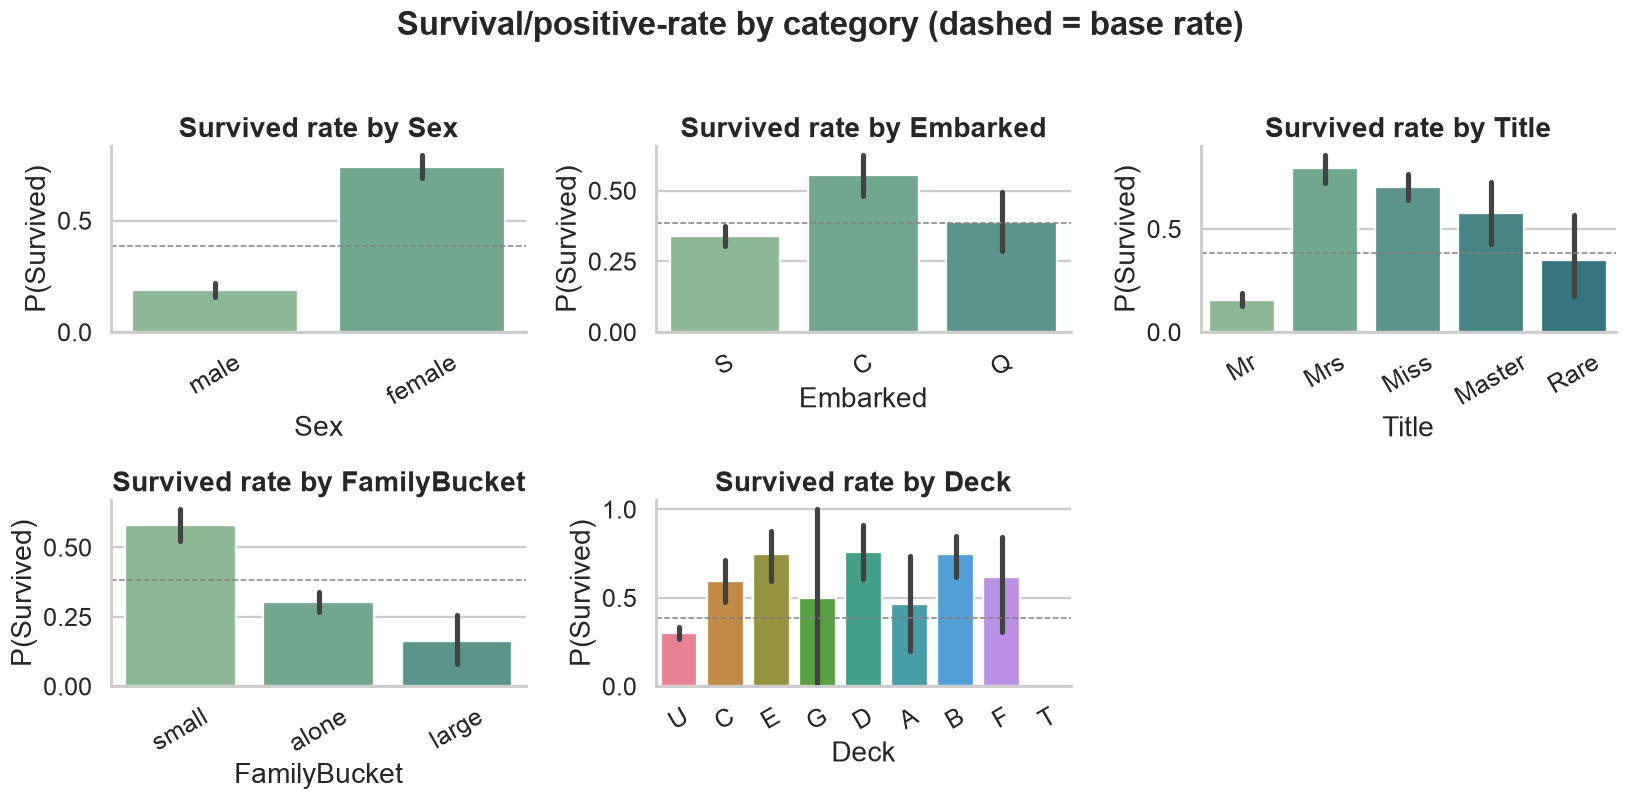

In [8]:
is_binary = train[TARGET].nunique() == 2
drivers = [c for c in cat_cols if c != TARGET]
if is_binary and drivers:
    n = len(drivers); ncol = 3; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.6*nrow))
    for ax, c in zip(np.atleast_1d(axes).ravel(), drivers):
        sns.barplot(data=train, x=c, y=TARGET, ax=ax, errorbar=("ci", 95),
                    hue=c, legend=False)
        ax.axhline(train[TARGET].mean(), ls="--", color="grey", lw=1)
        ax.set_title(f"{TARGET} rate by {c}"); ax.set_ylabel(f"P({TARGET})")
        ax.tick_params(axis="x", rotation=30)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle("Survival/positive-rate by category (dashed = base rate)",
                 y=1.02, fontweight="bold")
    sns.despine(); plt.tight_layout(); plt.show()

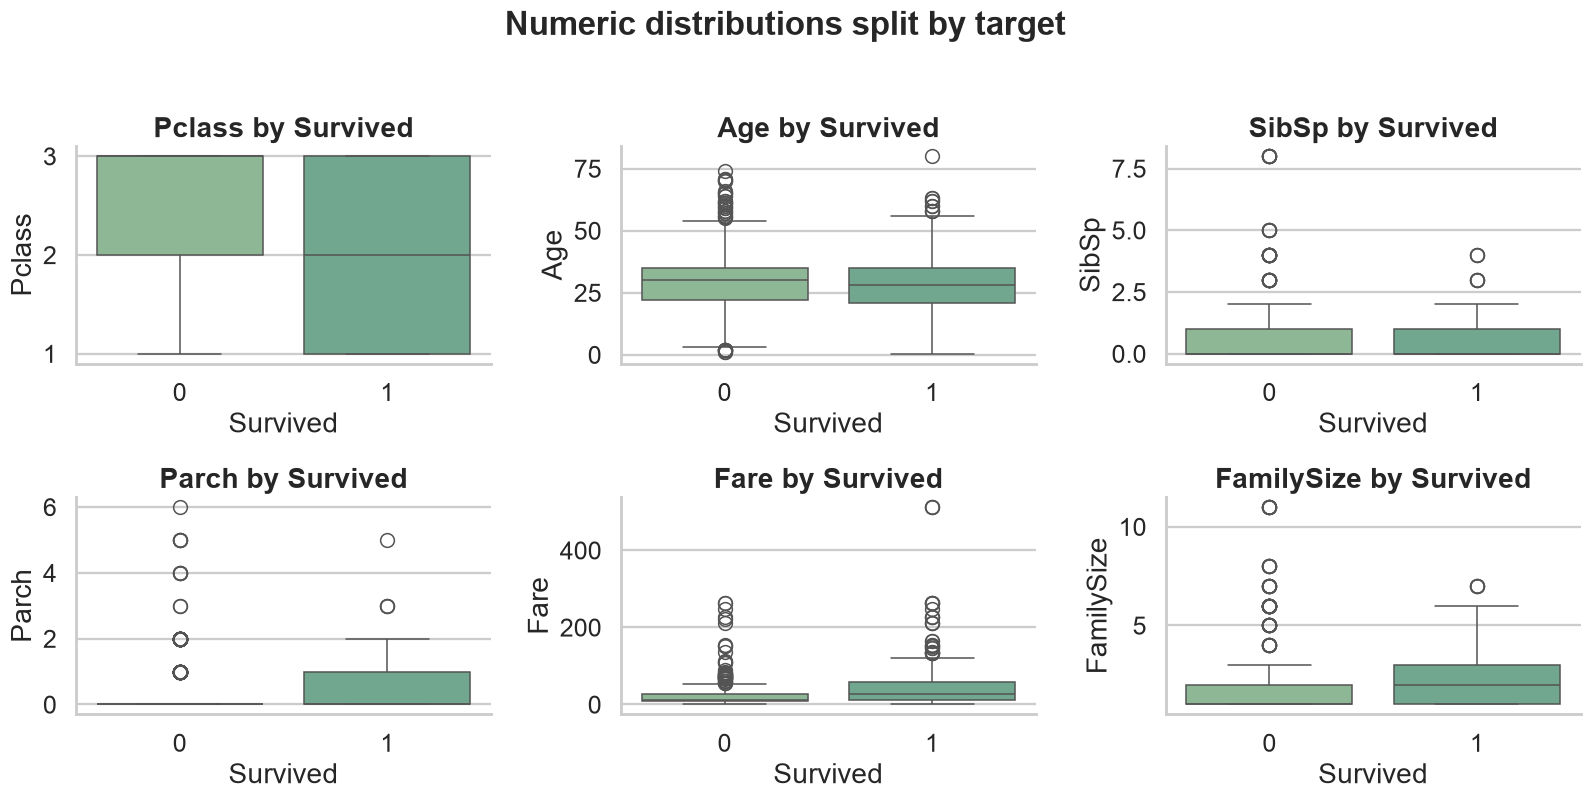

In [9]:
# Numeric features split by target class
if is_binary and num_cols:
    show = num_cols[:6]
    n = len(show); ncol = 3; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.6*nrow))
    for ax, c in zip(np.atleast_1d(axes).ravel(), show):
        sns.boxplot(data=train, x=TARGET, y=c, ax=ax, hue=TARGET, legend=False)
        ax.set_title(f"{c} by {TARGET}")
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle("Numeric distributions split by target", y=1.02, fontweight="bold")
    sns.despine(); plt.tight_layout(); plt.show()

## 5 · Correlation structure

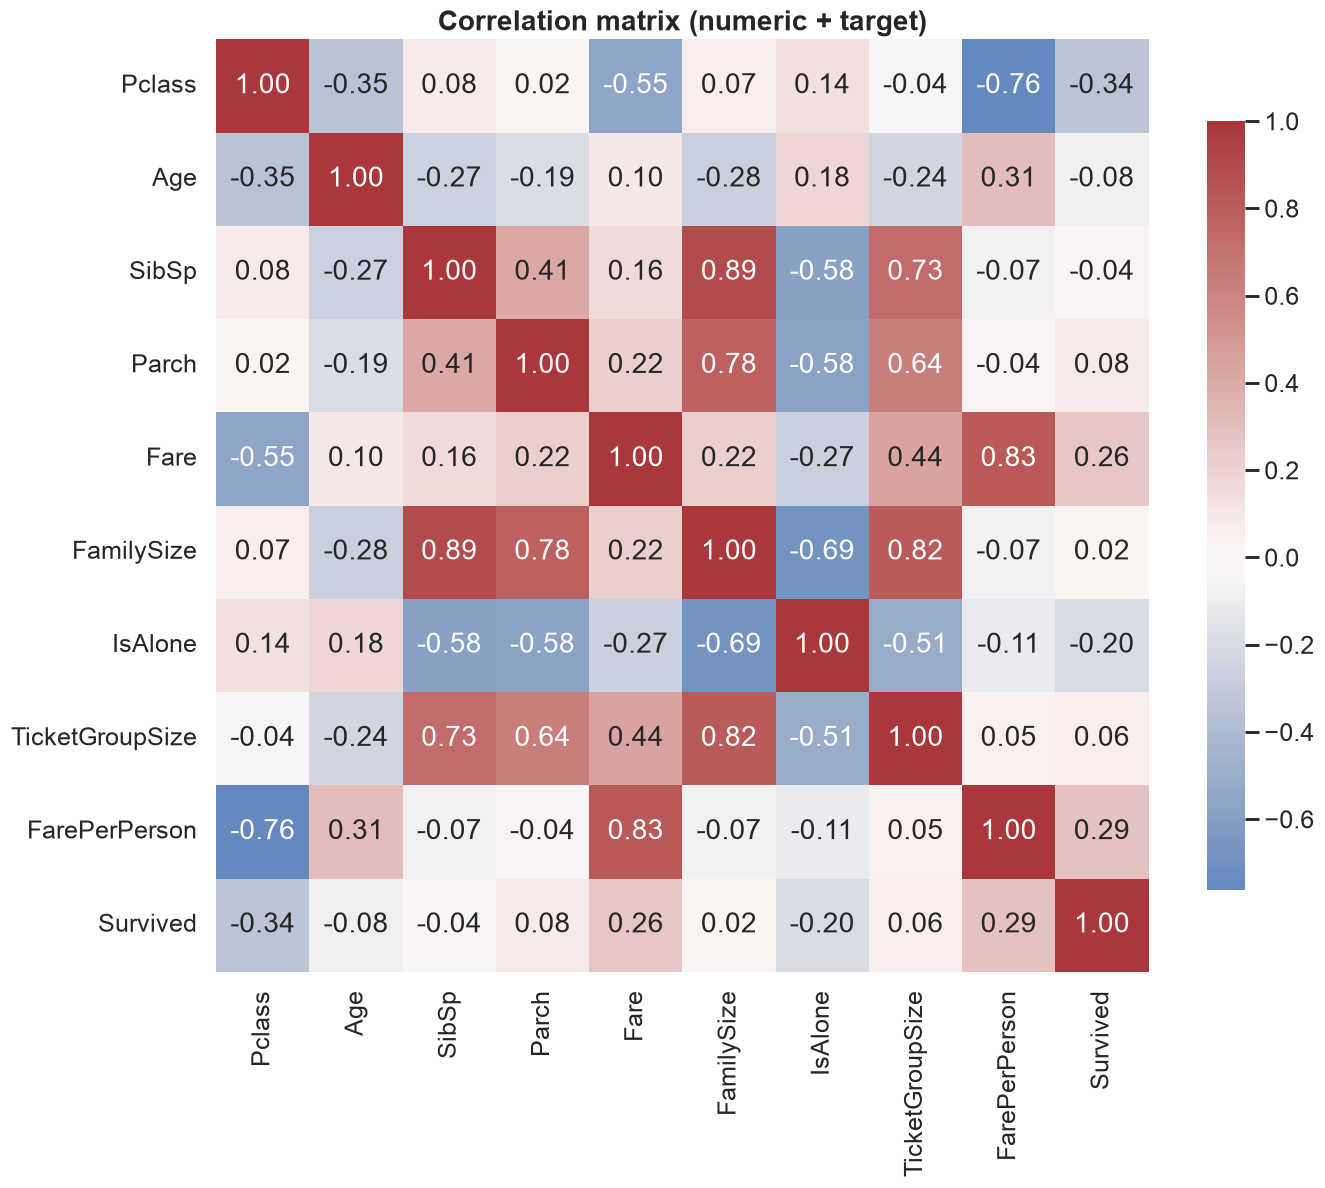

In [10]:
corr_df = train[num_cols + [TARGET]].copy()
if corr_df.shape[1] > 1:
    corr = corr_df.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(1.1*len(corr)+2, 1.0*len(corr)+1))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
                square=True, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title("Correlation matrix (numeric + target)")
    plt.tight_layout(); plt.show()

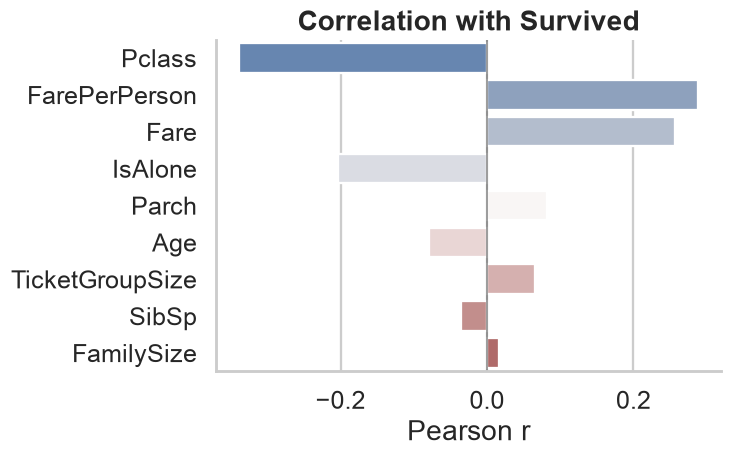

In [11]:
# Top absolute correlation with the target
if TARGET in train.columns and num_cols:
    tc = train[num_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
    tc = tc.reindex(tc.abs().sort_values(ascending=False).index)
    fig, ax = plt.subplots(figsize=(7, max(3, 0.5*len(tc))))
    sns.barplot(x=tc.values, y=tc.index, ax=ax, hue=tc.index, legend=False, palette="vlag")
    ax.axvline(0, color="grey", lw=1)
    ax.set_title(f"Correlation with {TARGET}"); ax.set_xlabel("Pearson r"); ax.set_ylabel("")
    sns.despine(); plt.tight_layout(); plt.show()

## 6 · Engineered-feature previews — *why these recipes*

These are the high-ROI derivations the feature-engineering agents target. Each is
computed here purely for visualization (target-free), so you can see the survival
signal each one exposes before the pipeline builds it. Titanic-specific cells no-op
on other competitions.

In [12]:
eng = train.copy()

# Title from Name (Titanic)
if "Name" in eng.columns:
    eng["Title"] = eng["Name"].str.extract(r",\s*([^\.]+)\.")
    rare = eng["Title"].value_counts()[lambda s: s < 10].index
    eng["Title"] = eng["Title"].replace(list(rare), "Rare")

# FamilySize / IsAlone
if {"SibSp", "Parch"}.issubset(eng.columns):
    eng["FamilySize"] = eng["SibSp"] + eng["Parch"] + 1
    eng["FamilyBucket"] = pd.cut(eng["FamilySize"], [0, 1, 4, 100],
                                 labels=["alone", "small", "large"])
    eng["IsAlone"] = (eng["FamilySize"] == 1).astype(int)

# Ticket group size + fare per person
if "Ticket" in eng.columns:
    eng["TicketGroupSize"] = eng.groupby("Ticket")["Ticket"].transform("count")
    if "Fare" in eng.columns:
        eng["FarePerPerson"] = eng["Fare"] / eng["TicketGroupSize"].clip(lower=1)

# Deck from Cabin
if "Cabin" in eng.columns:
    eng["Deck"] = eng["Cabin"].fillna("U").str[0]

preview = [c for c in ["Title","FamilyBucket","IsAlone","Deck"] if c in eng.columns]
preview_num = [c for c in ["FamilySize","TicketGroupSize","FarePerPerson"] if c in eng.columns]
print("Engineered categorical previews:", preview)
print("Engineered numeric previews:", preview_num)
eng[[c for c in preview+preview_num]].head()

Engineered categorical previews: ['Title', 'FamilyBucket', 'IsAlone', 'Deck']
Engineered numeric previews: ['FamilySize', 'TicketGroupSize', 'FarePerPerson']


,Title,FamilyBucket,IsAlone,Deck,FamilySize,TicketGroupSize,FarePerPerson
0,Mr,small,0,U,2,1,7.25000
1,Mrs,small,0,C,2,2,35.64165
2,Miss,alone,1,U,1,1,7.92500
3,Mrs,small,0,C,2,2,26.55000
4,Mr,alone,1,U,1,1,8.05000


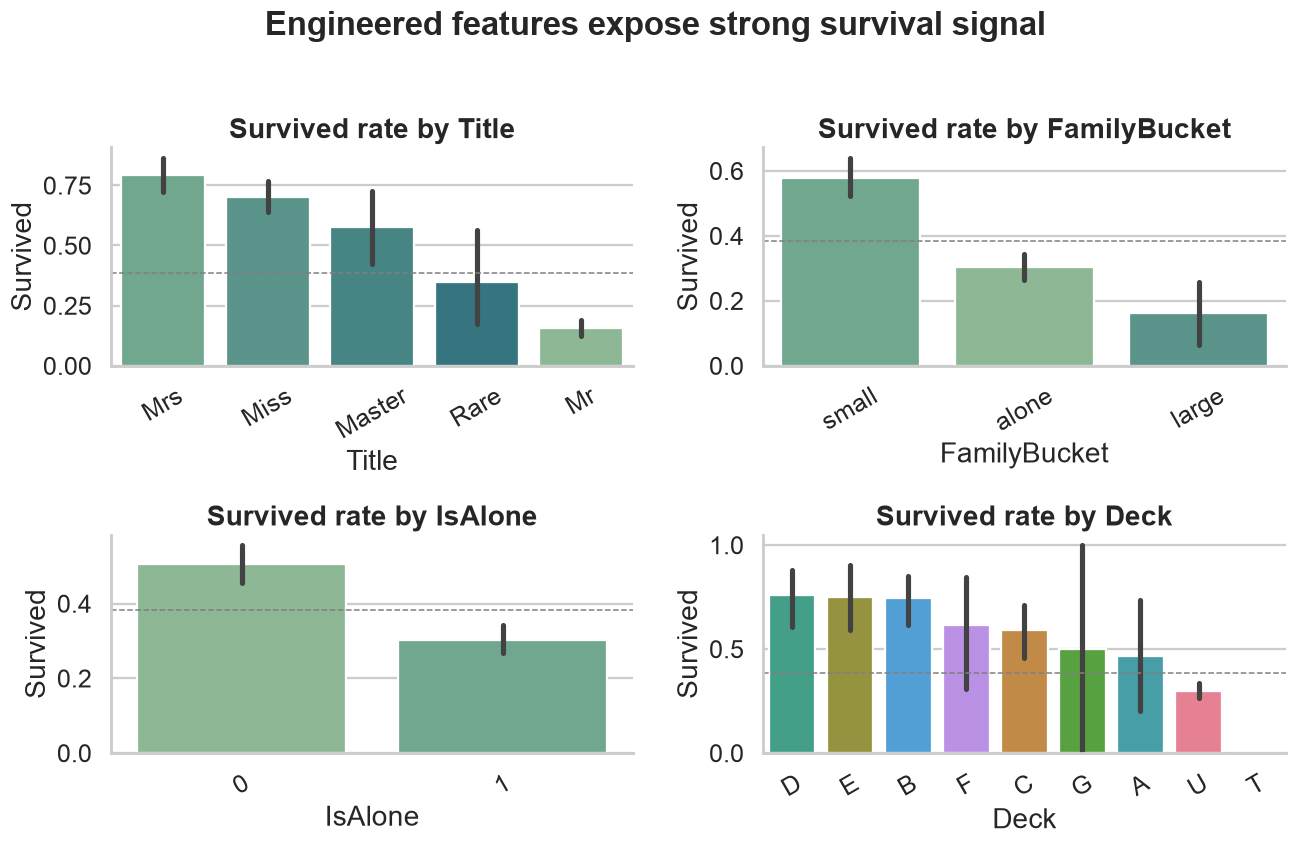

In [13]:
# Survival rate by each engineered categorical
if is_binary and preview:
    n = len(preview); ncol = 2; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6*ncol, 3.8*nrow))
    for ax, c in zip(np.atleast_1d(axes).ravel(), preview):
        order = eng.groupby(c)[TARGET].mean().sort_values(ascending=False).index
        sns.barplot(data=eng, x=c, y=TARGET, order=order, ax=ax, hue=c,
                    legend=False, errorbar=("ci", 95))
        ax.axhline(eng[TARGET].mean(), ls="--", color="grey", lw=1)
        ax.set_title(f"{TARGET} rate by {c}"); ax.tick_params(axis="x", rotation=30)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle("Engineered features expose strong survival signal",
                 y=1.02, fontweight="bold")
    sns.despine(); plt.tight_layout(); plt.show()

## 7 · Takeaways (auto-filled from `eda_summary.json`)

In [14]:
summary_path = Path(RUN_DIR) / "eda" / "eda_summary.json"
if summary_path.exists():
    s = json.loads(summary_path.read_text())
    tgt = s.get("target", {})
    print(f"Task: {tgt.get('task')}  |  rows: {tgt.get('n_rows')}")
    if "classes" in tgt:
        print("Class balance:", tgt["classes"], "| imbalance ratio:", tgt.get("imbalance_ratio"))
    print("\nTop |correlation| with target:")
    for k, v in list(s.get("target_correlation_top", {}).items())[:10]:
        print(f"  {k}: {v}")
    cols = s.get("columns", [])
    skew = [c["name"] for c in cols if c.get("numeric") and abs(c.get("skew",0))>1.5]
    miss = [c["name"] for c in cols if c.get("missing_pct",0)>5]
    highcard = [c["name"] for c in cols if not c.get("numeric") and c.get("n_unique",0)>30]
    print("\nSkewed numerics (log1p/power candidates):", skew or "none")
    print("Columns >5% missing (imputation matters):", miss or "none")
    print("High-cardinality categoricals (target-encode > one-hot):", highcard or "none")
else:
    print("eda_summary.json not found — run scripts/eda.py first.")

Task: classification  |  rows: 712
Class balance: {'0': 0.6166, '1': 0.3834} | imbalance ratio: 1.61

Top |correlation| with target:
  Pclass: 0.348
  FarePerPerson: 0.302
  Fare: 0.2755
  IsAlone: 0.2156
  Parch: 0.0842
  Age: 0.0834
  TicketGroupSize: 0.078
  FamilySize: 0.027
  SibSp: 0.0261

Skewed numerics (log1p/power candidates): ['SibSp', 'Parch', 'Fare', 'FamilySize', 'TicketGroupSize', 'FarePerPerson']
Columns >5% missing (imputation matters): none
High-cardinality categoricals (target-encode > one-hot): none


---
*Generated 20260713-0916 · `kaggle-ml-loop` · see the champion notebook for model results.*